In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor


In [ ]:

df=pd.read_csv('bodyfat.csv')

In [ ]:
df.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [ ]:
df.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [ ]:
df['BodyFat']==0

,BodyFat
0,False
1,False
2,False
3,False
4,False
...,...
247,False
248,False
249,False
250,False


In [ ]:
df.columns




Index(['Density', 'BodyFat', 'Age', 'Weight', 'Height', 'Neck', 'Chest',
       'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm',
       'Wrist'],
      dtype='object')

In [ ]:
print(f"Number of entries with BodyFat = 0: {(df['BodyFat']==0).sum()}")

Number of entries with BodyFat = 0: 1


In [ ]:


df=df[df['BodyFat']>0]

In [ ]:
print("The number of rows after removing bodyfat=0 is ",len(df))

The number of rows after removing bodyfat=0 is  251


In [ ]:
df = df.drop('Density',axis=1)

In [ ]:
df.head()

,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [ ]:

print(df[df['Height']<40])

    BodyFat  Age  Weight  Height  Neck  Chest  Abdomen    Hip  Thigh  Knee  \
41     32.9   44   205.0    29.5  36.6  106.0    104.3  115.5   70.6  42.5   

    Ankle  Biceps  Forearm  Wrist  
41   23.7    33.6     28.7   17.4  


In [ ]:
df = df[df['Height'] > 40]

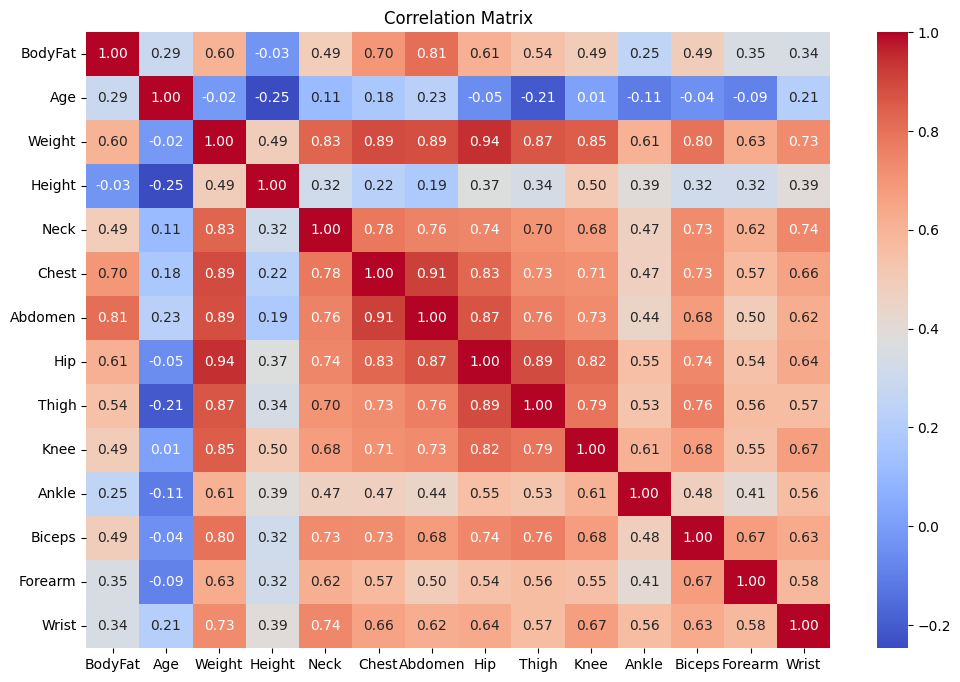

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


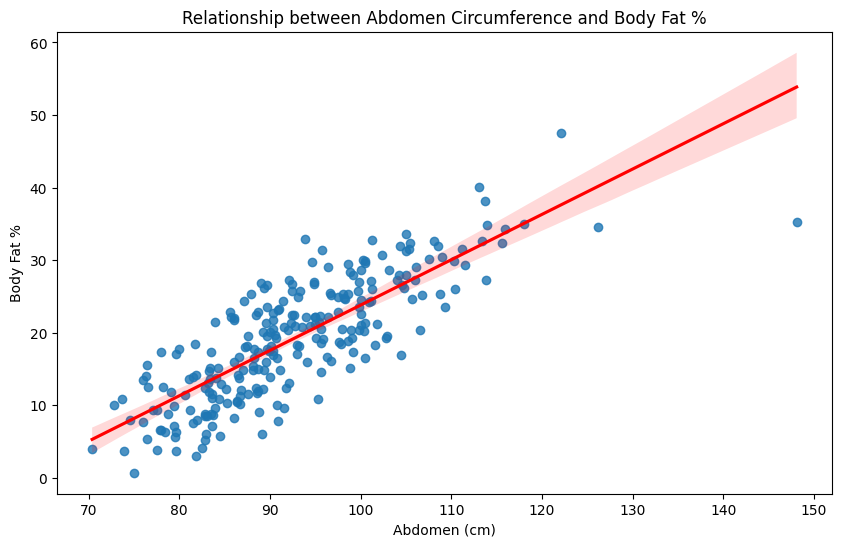

In [ ]:
# Plotting Abdomen vs BodyFat
plt.figure(figsize=(10, 6))
sns.regplot(x='Abdomen', y='BodyFat', data=df, line_kws={"color": "red"})
plt.title("Relationship between Abdomen Circumference and Body Fat %")
plt.xlabel("Abdomen (cm)")
plt.ylabel("Body Fat %")
plt.savefig("abdomen_vs_bodyfat.png")

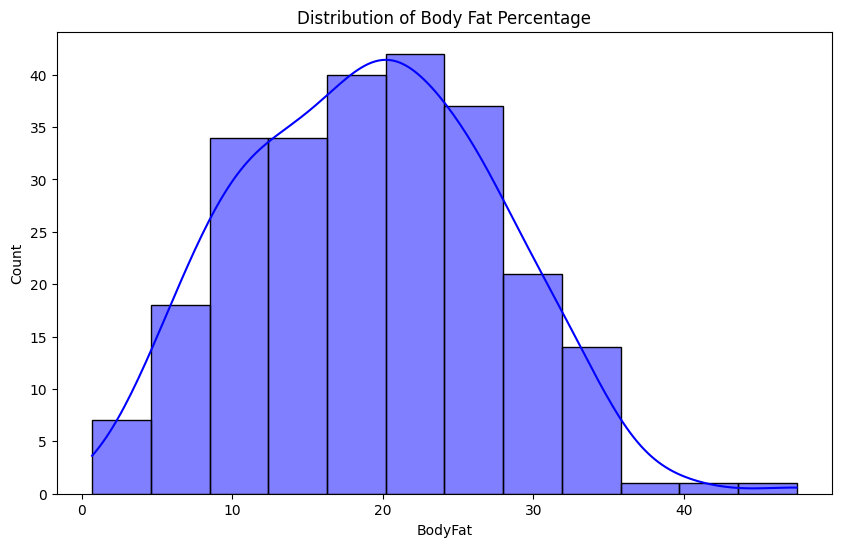

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['BodyFat'], kde=True, color='blue')
plt.title("Distribution of Body Fat Percentage")
plt.savefig("bodyfat_distribution.png")

In [ ]:
X=df.drop('BodyFat',axis=1)
y=df['BodyFat']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=100)

In [ ]:
#without feature engineering
model=LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
mae=mean_absolute_error(y_test,predictions)
r2=r2_score(y_test,predictions)

print(f"Mean Squared Error: {mae}")
print(f"R-squared: {r2}")


Mean Squared Error: 3.486725326638861
R-squared: 0.6678771121466944


In [ ]:

#RandomForest with normal data


X = df.drop('BodyFat', axis=1)
y = df['BodyFat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print(f"Random Forest R-squared: {r2_score(y_test, rf_preds)}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds)}")

Random Forest R-squared: 0.6656475808110065
Random Forest MAE: 3.490339999999998


In [ ]:
#Feature engineering and randomforest
df['BMI'] = (df['Weight'] * 703) / (df['Height'] ** 2)

df['Core_Ratio'] = df['Abdomen'] / df['Chest']

X = df.drop('BodyFat', axis=1)
y = df['BodyFat']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print(f"Feature Engineered R-squared: {r2_score(y_test, rf_preds)}")
print(f"Feature Engineered MAE: {mean_absolute_error(y_test, rf_preds)}")

Feature Engineered R-squared: 0.6826771009059159
Feature Engineered MAE: 3.414199999999998


In [ ]:


xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print(f"XGBoost R-squared: {r2_score(y_test, xgb_preds):.4f}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, xgb_preds):.4f}%")

XGBoost R-squared: 0.6574
XGBoost MAE: 3.6495%


/tmp/ipykernel_7055/156279780.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R-Squared', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_7055/156279780.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[1], palette='flare')


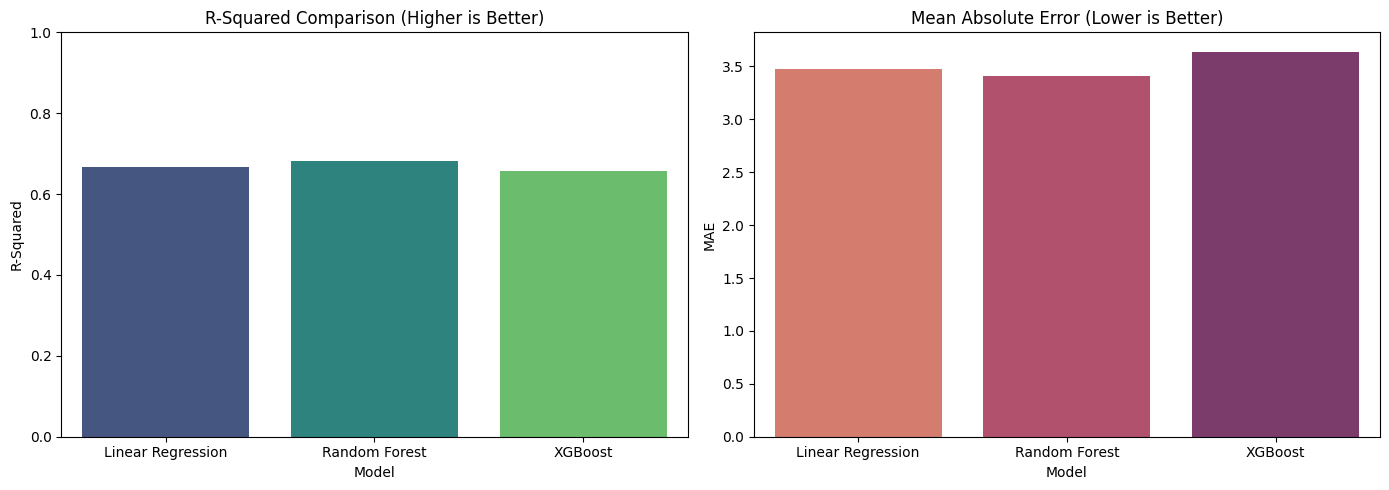

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a small dataframe of your results
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R-Squared': [0.667, 0.682, 0.657],  # Replace with your exact numbers if they differ
    'MAE': [3.48, 3.41, 3.64]            # Replace with your exact numbers if they differ
})

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Model', y='R-Squared', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('R-Squared Comparison (Higher is Better)')
axes[0].set_ylim(0, 1)

sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[1], palette='flare')
axes[1].set_title('Mean Absolute Error (Lower is Better)')

plt.tight_layout()
plt.show()

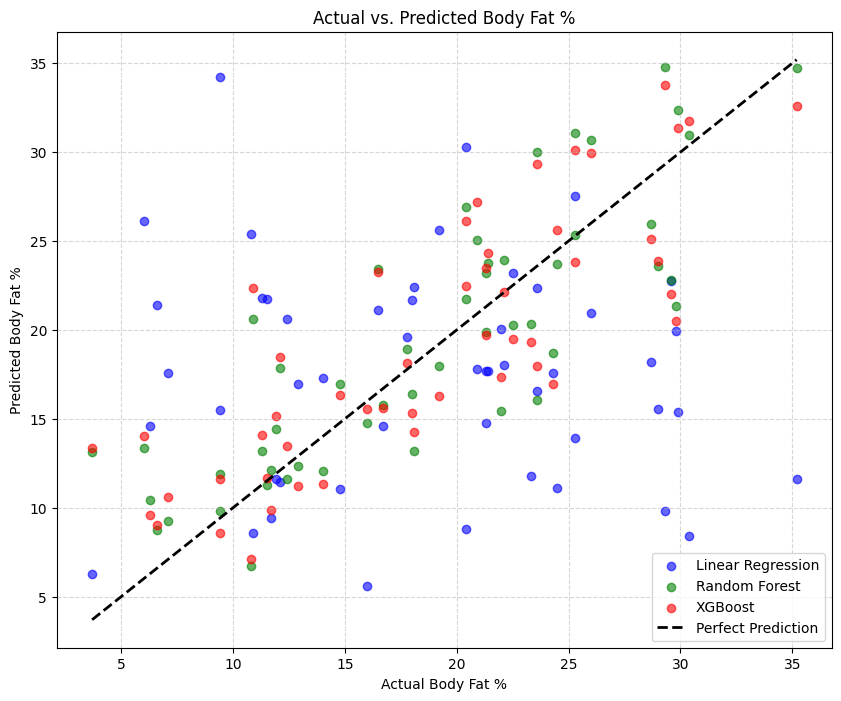

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(y_test, predictions, alpha=0.6, label='Linear Regression', color='blue')
plt.scatter(y_test, rf_preds, alpha=0.6, label='Random Forest', color='green')
plt.scatter(y_test, xgb_preds, alpha=0.6, label='XGBoost', color='red')


plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Body Fat %')
plt.xlabel('Actual Body Fat %')
plt.ylabel('Predicted Body Fat %')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

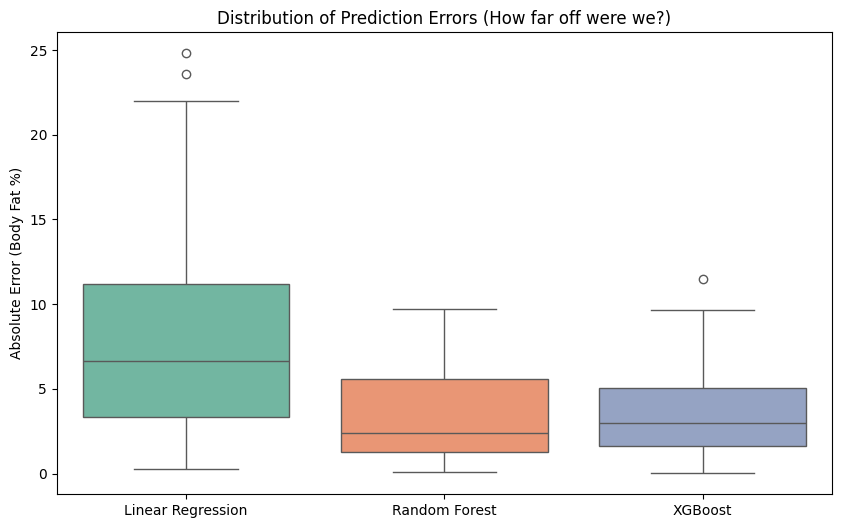

In [ ]:
import numpy as np


lr_errors = np.abs(y_test - predictions)
rf_errors = np.abs(y_test - rf_preds)
xgb_errors = np.abs(y_test - xgb_preds)

errors_df = pd.DataFrame({
    'Linear Regression': lr_errors,
    'Random Forest': rf_errors,
    'XGBoost': xgb_errors
})

plt.figure(figsize=(10, 6))

sns.boxplot(data=errors_df, palette='Set2')
plt.title('Distribution of Prediction Errors (How far off were we?)')
plt.ylabel('Absolute Error (Body Fat %)')
plt.show()

<Figure size 1000x800 with 0 Axes>

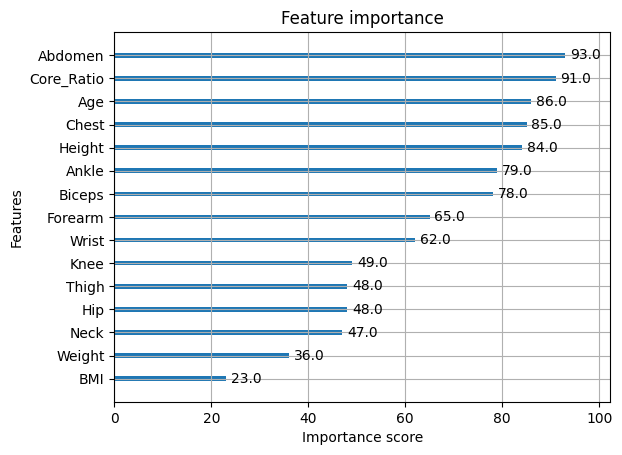

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(xgb_model)
plt.show()